In [ ]:
# Scrape the website API
import sys
sys.path.append("../src")

import requests
import pandas as pd
import time

all_levels = []
page = 1

while True:
    try:
        response = requests.get(
            "https://api.tuforums.com/v2/database/levels",
            params={"page": page, "limit": 500}, timeout=10
        )
    except requests.exceptions.RequestException as e:
        print(f"Error: {e}")
        break
    data = response.json()
    all_levels.extend(data["results"])

    print(f"Page {page} done | Total levels fetched so far: {len(all_levels)}")

    if not data["hasMore"]:
        break
    page += 1
    time.sleep(0.1)  # be polite to their server

print(f"Pulled {len(all_levels)} levels total")

Page 1 done | Total levels fetched so far: 100
Page 2 done | Total levels fetched so far: 200
Page 3 done | Total levels fetched so far: 300
Page 4 done | Total levels fetched so far: 400
Page 5 done | Total levels fetched so far: 500
Page 6 done | Total levels fetched so far: 600
Page 7 done | Total levels fetched so far: 700
Page 8 done | Total levels fetched so far: 800
Page 9 done | Total levels fetched so far: 900
Page 10 done | Total levels fetched so far: 1000
Page 11 done | Total levels fetched so far: 1100
Page 12 done | Total levels fetched so far: 1200
Page 13 done | Total levels fetched so far: 1300
Page 14 done | Total levels fetched so far: 1400
Page 15 done | Total levels fetched so far: 1500
Page 16 done | Total levels fetched so far: 1600
Page 17 done | Total levels fetched so far: 1700
Page 18 done | Total levels fetched so far: 1800
Page 19 done | Total levels fetched so far: 1900
Page 20 done | Total levels fetched so far: 2000
Page 21 done | Total levels fetched so

In [11]:
TIER_VALUES = {"P": 0, "G": 20, "U": 40} # Assign values for each tier so that the AI may be fed data easily. 

rated_levels = []


for level in all_levels:
    diff = level.get("difficulty")
    level_id = level["id"]
    level["dlLink"] = f"https://api.tuforums.com/v2/database/levels/{level_id}/level.adofai"
    if isinstance(diff, dict):
        tier = diff.get("name")
        tier_upper = tier.upper() if tier else "" # Removing Q Tiers
        # Skip junk tiers
        if tier and not tier_upper.startswith(("Q", "PQ", "GQ", "UQ")) and tier not in ["SPECIAL", "Censored", "Impossible", "Unranked"]:
            level["difficulty"] = tier
            level["tuforums_link"] = f"https://tuforums.com/levels/{level.get('id')}" # Link to TUForums ADOFAI chart

            ms = level.get("levelLengthInMs")
            if ms is None or float(ms) == 0:
                print(f"Skipping level {level_id}: missing/invalid levelLengthInMs")
                continue
            level["levelLengthInMs"] = round(float(ms) / 1000, 1) # Calculates song duration

            tile_count = level.get("tilecount")
            if tile_count is None or float(tile_count) == 0:
                print(f"Skipping level {level_id}: missing/invalid tilecount")
                continue
            tile_count_val = float(tile_count)

            level["density"] = ms / tile_count_val # Chart density formula

            # Convert PGU ratings into numbers for AI training (NOT LEGACY ADOFAI RATING) e.g. P5 = 5, G10 = 30 (20+10), U10 = 50 (40+10)
            tier_letter = tier_upper[0]
            tier_number = tier[1:]

            if tier_letter in TIER_VALUES and tier_number.isdigit():
                level["difficulty_number"] = TIER_VALUES[tier_letter] + int(tier_number)
            else:
                print(f"Could not parse difficulty '{tier}' for level {level_id}, skipping")
                continue  

            rated_levels.append(level)



NameError: name 'all_levels' is not defined

In [10]:
df = pd.DataFrame(rated_levels)
print(df.shape)

NameError: name 'rated_levels' is not defined

In [ ]:
# Function for parsing .adofai levels (twirl count, speed change count)

def extract_gameplay_features(level_json):
    actions = level_json.get("actions", [])
    
    twirl_count = 0
    speed_change_count = 0
    
    for action in actions:
        event_type = action.get("eventType")
        if event_type == "Twirl":
            twirl_count += 1
        elif event_type == "SetSpeed":
            speed_change_count += 1
    
    return {
        "twirl_count": twirl_count,
        "speed_change_count": speed_change_count,
    }

In [27]:
# Parsing .adofai levels

import time

gameplay_features = []

for i, row in df.iterrows():
    try:
        resp = requests.get(row["dlLink"], timeout=10)
        level_json = resp.json()

        # Filters any errors
        if "error" in level_json:
            print(f"Skipping id {row['id']}: {level_json['error']}")
            continue

        features = extract_gameplay_features(level_json)
        features["id"] = row["id"]
        gameplay_features.append(features)
    except Exception as e:
        print(f"Error: Failed on id {row['id']} ({e})")

    time.sleep(0.5)
print(f"Succesfully gained features for {len(gameplay_features)} levels.")

Skipping id 16253: Level .adofai file not found
Skipping id 15603: Level .adofai file not found
Skipping id 15358: Level .adofai file not found
Skipping id 15199: Level .adofai file not found
Skipping id 14911: Level .adofai file not found
Skipping id 14134: Level .adofai file not found
Skipping id 13917: Level .adofai file not found
Skipping id 13706: Level .adofai file not found
Skipping id 13481: Level .adofai file not found
Skipping id 13259: Level .adofai file not found
Skipping id 13246: Level .adofai file not found
Skipping id 13245: Level .adofai file not found
Skipping id 13240: Level .adofai file not found
Skipping id 13211: Level .adofai file not found
Skipping id 13209: Level .adofai file not found
Skipping id 13208: Level .adofai file not found
Skipping id 13188: Level .adofai file not found
Skipping id 13186: Level .adofai file not found
Skipping id 13184: Level .adofai file not found
Skipping id 13182: Level .adofai file not found
Skipping id 13181: Level .adofai file no

In [8]:
import sys, os

src_path = os.path.abspath("src")

sys.path.append(src_path)
from db import get_db

In [9]:
df.dropna(subset=["twirl_count", "speed_change_count"]) # Drops missing values in twirl_count and speed_change_count

schema_columns = [
    "id", "song", "creator", "difficulty", "difficulty_number", "tilecount",
    "levelLengthInMs", "bpm", "tuforums_link", "dlLink", "density", "twirl_count", "speed_change_count"
]


df_to_save = df.reindex(columns=schema_columns)
print(df_to_save.shape)

with get_db() as con:
    con.execute("""
        CREATE TABLE IF NOT EXISTS raw_levels (
            id INTEGER PRIMARY KEY,
            song TEXT,
            creator TEXT,
            difficulty REAL,
            difficulty_number REAL,
            tilecount INTEGER,
            levelLengthInMs INTEGER,
            bpm REAL,
            tuforums_link TEXT,
            dlLink TEXT,
            density INTEGER,
            twirl_count INTEGER,
            speed_change_count INTEGER
        )    
    """)


    df_to_save.to_sql("raw_levels", con, if_exists="replace", index=False)
print("Databased saved for deep learning.")


NameError: name 'df' is not defined

In [9]:
# Testing graphs

import matplotlib.pyplot as plt
import pandas as pd

with get_db() as con:
    df = pd.read_sql("SELECT * FROM raw_levels", con)

print(df.head())
print(df.columns.tolist())

      id                                 song                  creator  \
0  16725                ΩΩPARTS (Effect ver.)   Nephrolepis | Xoqmfflt   
1  16706    Parodia Sonatina -Grande- 4K only        Everlyn | Everlyn   
2  16704                         M.O.P.E.-333        Everlyn | Everlyn   
3  16685  Shelter (ft. Madeon) [Extended Mix]              Team Ashell   
4  16543                  Dreams (Remastered)  1KOSAHEDR4 | 1KOSAHEDR4   

  difficulty  difficulty_number  tilecount  levelLengthInMs    bpm  \
0        G19                 39          0            396.1  240.0   
1         U8                 48       5982            363.8  240.0   
2         U7                 47       4377            103.9  666.0   
3         P4                  4        630            254.7  100.0   
4         P1                  1         89            188.9   76.5   

                       tuforums_link  \
0  https://tuforums.com/levels/16725   
1  https://tuforums.com/levels/16706   
2  https://tuf

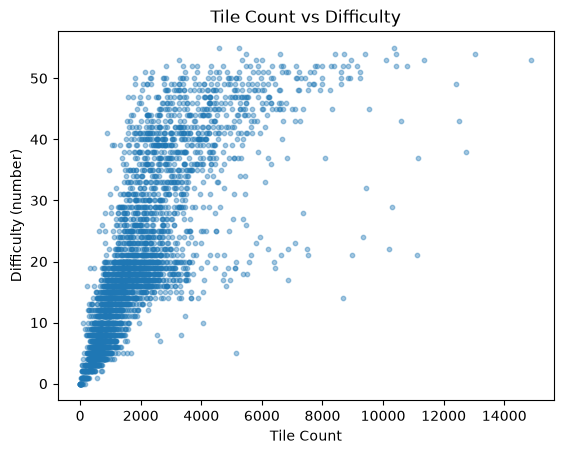

In [40]:
# Tilecount VS Difficulty Graph

plt.scatter(df["tilecount"], df["difficulty_number"], alpha=0.4, s=10)
plt.xlabel("Tile Count")
plt.ylabel("Difficulty (number)")
plt.title("Tile Count vs Difficulty")
plt.show()

In [41]:
print((df["density"] == 0).sum())

import numpy as np

df["log_density"] = np.log(df["density"])

0


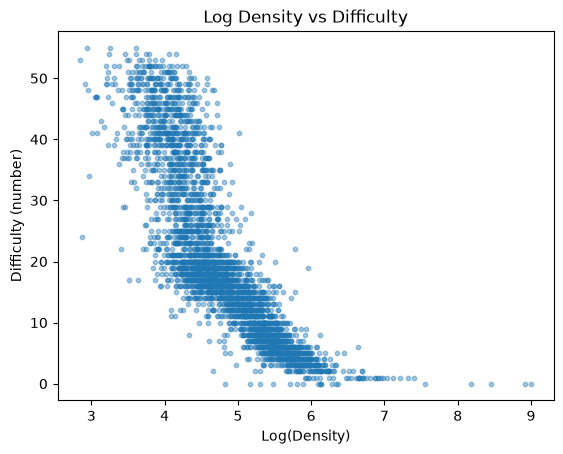

In [42]:
# Log density vs difficulty (best correlation graph)

plt.scatter(df["log_density"], df["difficulty_number"], alpha=0.4, s=10)
plt.xlabel("Log(Density)")
plt.ylabel("Difficulty (number)")
plt.title("Log Density vs Difficulty")
plt.show()

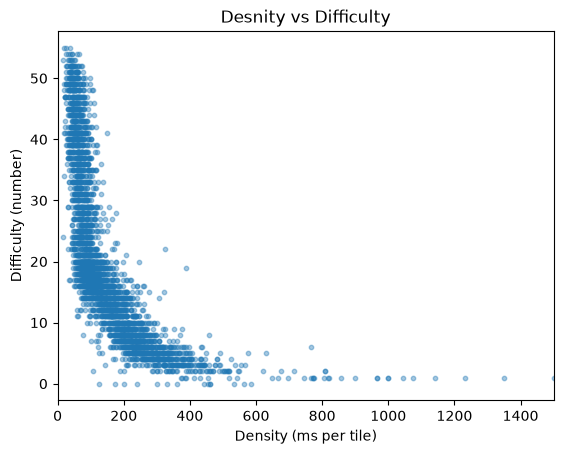

In [43]:
# Density VS Difficulty Graph

plt.scatter(df["density"], df["difficulty_number"], alpha=0.4, s=10)
plt.xlabel("Density (ms per tile)")
plt.ylabel("Difficulty (number)")
plt.title("Desnity vs Difficulty")
plt.xlim(0,1500)
plt.show()

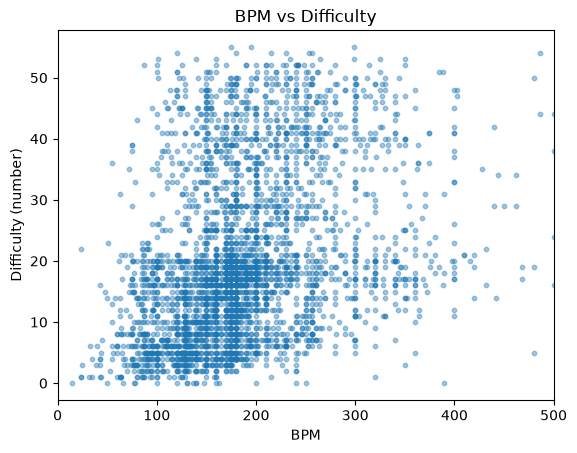

In [ ]:
# BPM VS Difficulty Graph

plt.scatter(df["bpm"], df["difficulty_number"], alpha=0.4, s=10)
plt.xlabel("BPM")
plt.ylabel("Difficulty (number)")
plt.title("BPM vs Difficulty")
plt.xlim(0, 500)
plt.show()

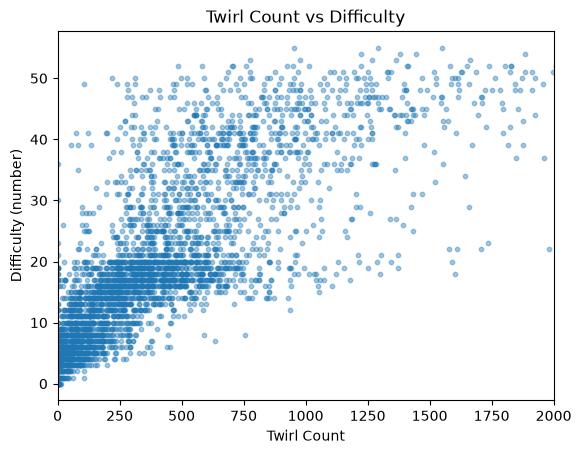

In [55]:
# Twirl Count VS Difficulty Graph

plt.scatter(df["twirl_count"], df["difficulty_number"], alpha=0.4, s=10)
plt.xlabel("Twirl Count")
plt.ylabel("Difficulty (number)")
plt.title("Twirl Count vs Difficulty")
plt.xlim(0,2000)
plt.show()

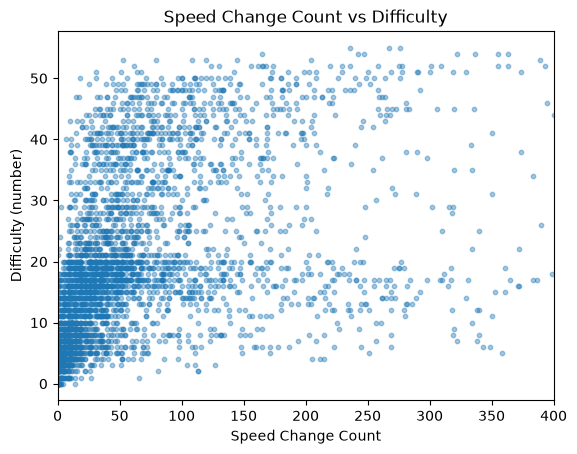

In [54]:
# Speed Change Count VS Difficulty Graph

plt.scatter(df["speed_change_count"], df["difficulty_number"], alpha=0.4, s=10)
plt.xlabel("Speed Change Count")
plt.ylabel("Difficulty (number)")
plt.title("Speed Change Count vs Difficulty")
plt.xlim(0,400)
plt.show()

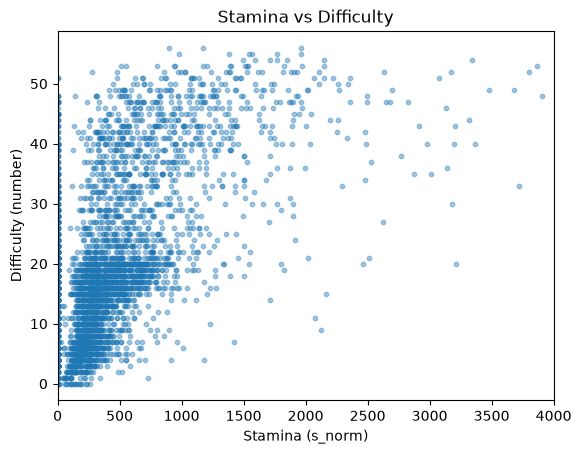

In [14]:
plt.scatter(df["s_norm"], df["difficulty_number"], alpha=0.4, s=10)
plt.xlabel("Stamina (s_norm)")
plt.ylabel("Difficulty (number)")
plt.title("Stamina vs Difficulty")
plt.xlim(0,4000)
plt.show()

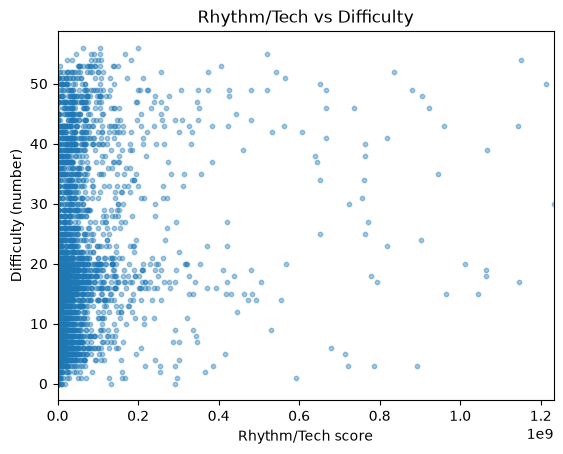

In [13]:
plt.scatter(df["rt_score"], df["difficulty_number"], alpha=0.4, s=10)
plt.xlabel("Rhythm/Tech score")
plt.ylabel("Difficulty (number)")
plt.title("Rhythm/Tech vs Difficulty")
plt.xlim(0, df["rt_score"].quantile(0.99))
plt.show()

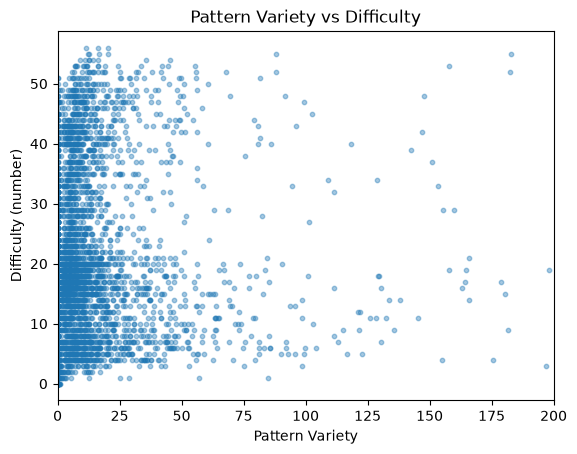

In [16]:
plt.scatter(df["p_var"], df["difficulty_number"], alpha=0.4, s=10)
plt.xlabel("Pattern Variety")
plt.ylabel("Difficulty (number)")
plt.title("Pattern Variety vs Difficulty")
plt.xlim(0,200)
plt.show()

In [8]:
# AI model using LIGHTGBM (still learning)

import lightgbm as lgb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_absolute_error, mean_squared_error

num_round = 100
params = {
    "objective": "regression",
    "metric": "rmse",
    "verbosity": 1,
}

with get_db() as con:
    df = pd.read_sql_query("SELECT * FROM raw_levels", con)

X = df.drop(columns=["difficulty", "difficulty_number", "id", "song", "creator", "tuforums_link", "dlLink", "density", "levelLengthInMs"])
y = df["difficulty_number"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

model = lgb.train(params, train_data, num_boost_round=num_round, valid_sets=[test_data])

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

importance = pd.Series(model.feature_importance(), index=X.columns).sort_values(ascending=False)
model.save_model("difficulty_model.txt")
print(importance)


DatabaseError: Execution failed on sql 'SELECT * FROM raw_levels': no such table: raw_levels

In [2]:
# Function for predicting level difficulty

import json
import requests
import pandas as pd

def num_to_pgu(number):
    rounded = round(number)
    clamped = max(1, min(rounded, 60))

    if clamped <= 20:
        letter = "P"
        tier_number = clamped
    elif clamped <= 40:
        letter = "G"
        tier_number = clamped - 20
    elif clamped <= 60:
        letter = "U"
        tier_number = clamped - 40
    return f"{letter}{tier_number}"

def extract_features_from_file(level_json):
    settings = level_json.get("settings", {})
    angle_data = level_json.get("angleData", [])
    actions = level_json.get("actions", [])

    tile_count = len(angle_data)
    bpm = settings.get("bpm", 0)

    twirl_count = 0
    speed_change_count = 0

    for action in actions:
        event_type = action.get("eventType")
        if event_type == "Twirl":
            twirl_count += 1
        elif event_type == "SetSpeed":
            speed_change_count += 1
    return {
        "tilecount": tile_count,
        "bpm": bpm,
        "twirl_count": twirl_count,
        "speed_change_count": speed_change_count,
    }
def predict_difficulty(level_json, model):
    features = extract_features_from_file(level_json)
    X_input = pd.DataFrame([features])
    predicted_number = model.predict(X_input)[0]
    return num_to_pgu(predicted_number), predicted_number

In [5]:
# User Input (TERMINAL)
# This is used to test on already rated levels to verify it works. 
# The ai will probably give something innacurate especially with higher difficulties and any outliers in events.
def run_ai_predictor(show_features=False):
    print("Paste in a TUF .adofai download link, or type 'quit' to exit. \n")
    while True:
        dl_link = input("Enter .adofai link: ").strip()

        if dl_link.lower() == "quit":
            print("Goodbye!")
            break
        try:
            response = requests.get(dl_link, timeout=10)
            response.raise_for_status()
            level_json = response.json()

            tier, raw_number = predict_difficulty(level_json, model)
            print(f"Predicted difficulty: {tier} (raw score: {raw_number:.2f})\n")

            if show_features:
                features = extract_features_from_file(level_json)
                print(features)
        except Exception as e:
            print(f"Error: {e}")
run_ai_predictor()

Paste in a TUF .adofai download link, or type 'quit' to exit. 

Error: name 'model' is not defined
Error: name 'model' is not defined
Goodbye!
